In [1]:
"""
Experimental Fluid Mechanics: Centrifugal Pump Arrangement Analysis
Objective: Characterize and compare the performance of two centrifugal pumps operating
in different configurations: individual operation, series arrangement, and parallel arrangement.
Experimental data is compared with both individual pump performance and theoretical
predictions based on arrangement laws.

Pump Configurations Tested:
- Individual Operation: Each pump tested separately under standard conditions
- Series Arrangement: Pumps connected in series (additive heads for same flow rate)
- Parallel Arrangement: Pumps connected in parallel (additive flow rates for same head)

Experimental Methodology:
- Five measurement points recorded for each pump configuration
- Pressure readings from differential pressure transducers
- Flow rate measurements via calibrated orifice plate or flowmeter
- All measurements include uncertainty quantification for error propagation
- Manometric head (H) calculated from pressure differential and elevation difference
- 2nd degree polynomial fitting for smooth performance curve characterization
- Experimental results compared with theoretical predictions for validation

Libraries Used:
- pandas: Data organization and manipulation in DataFrames
- numpy: Numerical computations and polynomial fitting
- uncertainties: Automatic error propagation from measurements
- CoolProp: High-accuracy thermodynamic property calculations (water density)
- matplotlib: Visualization of performance curves and comparative analysis
"""

import pandas as pd
from uncertainties import ufloat, wrap
import numpy as np
import CoolProp.CoolProp as CP
import matplotlib.pyplot as plt

print("Libraries and environment setup complete. Ready for pump arrangement analysis.")

Libraries and environment setup complete. Ready for pump arrangement analysis.


In [2]:
"""
STEP 1: ENVIRONMENTAL CONDITIONS, CONVERSION FACTORS, AND DATA LOADING

Initialize all experimental parameters, measurement uncertainties, and conversion factors,
then load experimental data for all pump configurations (individual, series, and parallel).
All calculations use SI units consistently.
"""

# ============================================================================
# ENVIRONMENTAL CONDITIONS WITH MEASUREMENT UNCERTAINTIES
# ============================================================================
# Values recorded during laboratory session with instrument precision limits

P_atm_mmHg = ufloat(698.0, 0.5)          # Atmospheric pressure [mmHg] ± 0.5 mmHg
T_amb_C = ufloat(22.0, 0.5)              # Ambient temperature [°C] ± 0.5 °C
g = ufloat(9.78, 0.01)                   # Gravitational acceleration [m/s²] ± 0.01 m/s²

# ============================================================================
# UNIT CONVERSION FACTORS (Exact Constants - No Uncertainty)
# ============================================================================
# Physical constants for unit conversions

Pa_por_atm = 101325.0                    # Conversion: 1 atm = 101325 Pa
Pa_por_mmHg_const = 133.322              # Conversion: 1 mmHg = 133.322 Pa
m3_por_L = 0.001                         # Conversion: 1 m³ = 1000 L
s_por_h = 3600.0                         # Conversion: 1 hour = 3600 seconds
m_por_cm = 0.01                          # Conversion: 1 m = 100 cm

# ============================================================================
# CONVERT ENVIRONMENTAL PROPERTIES TO SI UNITS
# ============================================================================
# All calculations require consistent SI unit system

T_amb_K = T_amb_C + 273.15               # Ambient temperature [K]
P_atm_Pa = P_atm_mmHg * Pa_por_mmHg_const  # Atmospheric pressure [Pa]

# Retrieve water density at measured ambient conditions using CoolProp
rho_agua = CP.PropsSI('D', 'T', T_amb_K.nominal_value, 'P', P_atm_Pa.nominal_value, 'Water')

# Conversion factor from water column height to pressure (cmH₂O → Pa)
Pa_por_cmH2O = rho_agua * g * m_por_cm

print("Environmental constants and conversion factors initialized.")
print(f"  Ambient conditions: T = {T_amb_C} °C, P = {P_atm_mmHg} mmHg")
print(f"  Water density at ambient: {rho_agua:.2f} kg/m³")
print(f"  Conversion factor (cmH₂O → Pa): {Pa_por_cmH2O:.2f} Pa/cmH₂O")

# ============================================================================
# PUMP 1 (SUPERIOR): Individual Operation
# ============================================================================
# Both discharge and suction pressures measured in atmospheres

data_superior = {
    'P_r_sup_atm': [ufloat(2.30, 0.05), ufloat(2.50, 0.05), ufloat(2.60, 0.05), ufloat(2.70, 0.05), ufloat(2.80, 0.05)],
    'P_s_sup_atm': [ufloat(-0.10, 0.05), ufloat(-0.10, 0.05), ufloat(-0.10, 0.05), ufloat(0.00, 0.05), ufloat(0.00, 0.05)],
    'Q_sup_Lh': [ufloat(7500, 250), ufloat(6000, 250), ufloat(5000, 250), ufloat(4000, 250), ufloat(3000, 250)]
}
df_superior = pd.DataFrame(data_superior, index=range(1, 6))
df_superior.index.name = 'Measurement Point'
df_superior['Q_sup_m3h'] = df_superior['Q_sup_Lh'] * m3_por_L
m_sup_m = ufloat(38.40, 0.05) * m_por_cm  # Elevation offset [m]

# ============================================================================
# PUMP 2 (INFERIOR): Individual Operation
# ============================================================================
# Discharge in atmospheres, suction in water column height (cmH₂O)

data_inferior = {
    'P_r_inf_atm': [ufloat(2.150, 0.025), ufloat(2.400, 0.025), ufloat(2.500, 0.025), ufloat(2.700, 0.025), ufloat(2.750, 0.025)],
    'P_s_inf_cmH2O': [ufloat(40.20, 0.05), ufloat(42.70, 0.05), ufloat(44.10, 0.05), ufloat(45.40, 0.05), ufloat(47.40, 0.05)],
    'Q_inf_Lh': [ufloat(7500, 250), ufloat(6000, 250), ufloat(5000, 250), ufloat(4000, 250), ufloat(3000, 250)]
}
df_inferior = pd.DataFrame(data_inferior, index=range(1, 6))
df_inferior.index.name = 'Measurement Point'
df_inferior['Q_inf_m3h'] = df_inferior['Q_inf_Lh'] * m3_por_L
m_inf_m = ufloat(51.40, 0.05) * m_por_cm  # Elevation offset [m]

# ============================================================================
# PUMP 1 (SUPERIOR): Series Arrangement Configuration
# ============================================================================
# Same flow rates as individual, different pressure readings due to series arrangement

data_superior_paralelo = {
    'P_r_sup_atm': [ufloat(2.60, 0.05), ufloat(2.80, 0.05), ufloat(2.80, 0.05), ufloat(2.90, 0.05), ufloat(2.90, 0.05)],
    'P_s_sup_atm': [ufloat(-0.10, 0.05), ufloat(-0.10, 0.05), ufloat(0.00, 0.05), ufloat(0.00, 0.05), ufloat(0.00, 0.05)],
    'Q_sup_m3h': [ufloat(10.00, 0.25), ufloat(7.50, 0.25), ufloat(6.00, 0.25), ufloat(4.50, 0.25), ufloat(3.00, 0.25)]
}
df_superior_paralelo = pd.DataFrame(data_superior_paralelo, index=range(1, 6))
df_superior_paralelo.index.name = 'Measurement Point'

# ============================================================================
# PUMP 2 (INFERIOR): Series Arrangement Configuration
# ============================================================================

data_inferior_paralelo = {
    'P_r_inf_atm': [ufloat(2.450, 0.025), ufloat(2.650, 0.025), ufloat(2.700, 0.025), ufloat(2.750, 0.025), ufloat(2.750, 0.025)],
    'P_s_inf_cmH2O': [ufloat(43.70, 0.05), ufloat(45.60, 0.05), ufloat(46.40, 0.05), ufloat(46.90, 0.05), ufloat(47.40, 0.05)],
    'Q_inf_m3h': [ufloat(10.00, 0.25), ufloat(7.50, 0.25), ufloat(6.00, 0.25), ufloat(4.50, 0.25), ufloat(3.00, 0.25)]
}
df_inferior_paralelo = pd.DataFrame(data_inferior_paralelo, index=range(1, 6))
df_inferior_paralelo.index.name = 'Measurement Point'

# ============================================================================
# PUMPS IN SERIES: Combined Operation
# ============================================================================
# Pumps connected in series - heads add for same flow rate

data_bombas_serie = {
    'P_r_inf_atm': [ufloat(3.10, 0.05), ufloat(4.50, 0.05), ufloat(4.90, 0.05), ufloat(5.20, 0.05), ufloat(5.50, 0.05)],
    'P_s_inf_cmH2O': [ufloat(33.00, 0.05), ufloat(42.00, 0.05), ufloat(44.10, 0.05), ufloat(46.10, 0.05), ufloat(47.50, 0.05)],
    'Q_inf_m3h': [ufloat(10.00, 0.25), ufloat(7.50, 0.25), ufloat(6.00, 0.25), ufloat(4.50, 0.25), ufloat(3.00, 0.25)]
}
df_bombas_serie = pd.DataFrame(data_bombas_serie, index=range(1, 6))
df_bombas_serie.index.name = 'Measurement Point'

# ============================================================================
# PUMPS IN PARALLEL: Combined Operation
# ============================================================================
# Pumps connected in parallel - flow rates add for same head

data_paralelo = {
    'P_r_inf_atm': [ufloat(2.350, 0.05), ufloat(2.420, 0.05), ufloat(2.510, 0.05), ufloat(2.600, 0.05), ufloat(2.650, 0.05)],
    'P_s_inf_cmH2O': [ufloat(44.50, 0.05), ufloat(45.00, 0.05), ufloat(46.50, 0.05), ufloat(47.00, 0.05), ufloat(47.40, 0.05)],
    'Q_inf_Lh': [ufloat(10000, 250), ufloat(9000, 250), ufloat(8000, 250), ufloat(7000, 250), ufloat(6000, 250)]
}
df_paralelo = pd.DataFrame(data_paralelo, index=range(1, 6))
df_paralelo.index.name = 'Measurement Point'
df_paralelo['Q_inf_m3h'] = df_paralelo['Q_inf_Lh'] * m3_por_L

print("\nAll experimental data loaded successfully.")
print(f"  Pump 1 (Superior) - Individual: {len(df_superior)} measurement points")
print(f"  Pump 2 (Inferior) - Individual: {len(df_inferior)} measurement points")
print(f"  Pumps in Series: {len(df_bombas_serie)} measurement points")
print(f"  Pumps in Parallel: {len(df_paralelo)} measurement points")

Environmental constants and conversion factors initialized.
  Ambient conditions: T = 22.0+/-0.5 °C, P = 698.0+/-0.5 mmHg
  Water density at ambient: 997.77 kg/m³
  Conversion factor (cmH₂O → Pa): 97.58+/-0.10 Pa/cmH₂O

All experimental data loaded successfully.
  Pump 1 (Superior) - Individual: 5 measurement points
  Pump 2 (Inferior) - Individual: 5 measurement points
  Pumps in Series: 5 measurement points
  Pumps in Parallel: 5 measurement points


In [23]:
"""
STEP 2: DISPLAY RAW EXPERIMENTAL DATA - PUMP 1 (SUPERIOR) INDIVIDUAL OPERATION

This cell displays the raw measurements collected for Pump 1 (Superior) under individual operation.
The DataFrame shows:
- Discharge pressure (P_r_sup_atm) in atmospheres
- Suction pressure (P_s_sup_atm) in atmospheres (negative values indicate vacuum)
- Flow rate (Q_sup_Lh) in liters per hour
- Converted flow rate (Q_sup_m3h) in cubic meters per hour

All values are presented with their measurement uncertainties.
"""

print("=" * 100)
print("PUMP 1 (SUPERIOR): Individual Operation - Raw Experimental Measurements")
print("=" * 100)
print("\nConfiguration: Discharge and Suction Pressures in Atmospheres (atm)")
print("Number of measurement points: 5")
print("-" * 100)

df_superior

PUMP 1 (SUPERIOR): Individual Operation - Raw Experimental Measurements

Configuration: Discharge and Suction Pressures in Atmospheres (atm)
Number of measurement points: 5
----------------------------------------------------------------------------------------------------


,P_r_sup_atm,P_s_sup_atm,Q_sup_Lh,Q_sup_m3h,H_man (m)
Measurement Point,,,,,
1,2.30+/-0.05,-0.10+/-0.05,(7.50+/-0.25)e+03,7.50+/-0.25,25.3+/-0.7
2,2.50+/-0.05,-0.10+/-0.05,(6.00+/-0.25)e+03,6.00+/-0.25,27.4+/-0.7
3,2.60+/-0.05,-0.10+/-0.05,(5.00+/-0.25)e+03,5.00+/-0.25,28.4+/-0.7
4,2.70+/-0.05,0.00+/-0.05,(4.00+/-0.25)e+03,4.00+/-0.25,28.4+/-0.7
5,2.80+/-0.05,0.00+/-0.05,(3.00+/-0.25)e+03,3.00+/-0.25,29.5+/-0.7


In [4]:
"""
STEP 3: DISPLAY RAW EXPERIMENTAL DATA - PUMP 2 (INFERIOR) INDIVIDUAL OPERATION

This cell displays the raw measurements collected for Pump 2 (Inferior) under individual operation.
The DataFrame shows:
- Discharge pressure (P_r_inf_atm) in atmospheres
- Suction pressure (P_s_inf_cmH2O) in water column height (centimeters)
- Flow rate (Q_inf_Lh) in liters per hour
- Converted flow rate (Q_inf_m3h) in cubic meters per hour

Note the mixed pressure units: discharge in atm, suction in cmH₂O. Both will be converted to 
Pascals (Pa) for unified calculations.
"""

print("=" * 100)
print("PUMP 2 (INFERIOR): Individual Operation - Raw Experimental Measurements")
print("=" * 100)
print("\nConfiguration: Discharge in Atmospheres (atm), Suction in Water Column (cmH₂O)")
print("Number of measurement points: 5")
print("Note: Suction pressure directly from manometer reading (positive values)")
print("-" * 100)

df_inferior

PUMP 2 (INFERIOR): Individual Operation - Raw Experimental Measurements

Configuration: Discharge in Atmospheres (atm), Suction in Water Column (cmH₂O)
Number of measurement points: 5
Note: Suction pressure directly from manometer reading (positive values)
----------------------------------------------------------------------------------------------------


,P_r_inf_atm,P_s_inf_cmH2O,Q_inf_Lh,Q_inf_m3h
Measurement Point,,,,
1,2.150+/-0.025,40.20+/-0.05,(7.50+/-0.25)e+03,7.50+/-0.25
2,2.400+/-0.025,42.70+/-0.05,(6.00+/-0.25)e+03,6.00+/-0.25
3,2.500+/-0.025,44.10+/-0.05,(5.00+/-0.25)e+03,5.00+/-0.25
4,2.700+/-0.025,45.40+/-0.05,(4.00+/-0.25)e+03,4.00+/-0.25
5,2.750+/-0.025,47.40+/-0.05,(3.00+/-0.25)e+03,3.00+/-0.25


In [5]:
"""
STEP 4: DISPLAY RAW EXPERIMENTAL DATA - PUMP 1 (SUPERIOR) SERIES ARRANGEMENT

Raw measurements for Pump 1 operating in series arrangement with Pump 2.
When pumps are arranged in series, they are connected so that the discharge of one 
pump feeds into the suction of the next pump.
"""

print("=" * 100)
print("PUMP 1 (SUPERIOR): Series Arrangement Configuration - Raw Experimental Measurements")
print("=" * 100)
print("\nConfiguration: Series Arrangement (Pumps Connected in Series)")
print("Number of measurement points: 5")
print("-" * 100)

df_superior_paralelo

PUMP 1 (SUPERIOR): Series Arrangement Configuration - Raw Experimental Measurements

Configuration: Series Arrangement (Pumps Connected in Series)
Number of measurement points: 5
----------------------------------------------------------------------------------------------------


,P_r_sup_atm,P_s_sup_atm,Q_sup_m3h
Measurement Point,,,
1,2.60+/-0.05,-0.10+/-0.05,10.00+/-0.25
2,2.80+/-0.05,-0.10+/-0.05,7.50+/-0.25
3,2.80+/-0.05,0.00+/-0.05,6.00+/-0.25
4,2.90+/-0.05,0.00+/-0.05,4.50+/-0.25
5,2.90+/-0.05,0.00+/-0.05,3.00+/-0.25


In [6]:
"""
STEP 5: DISPLAY RAW EXPERIMENTAL DATA - PUMP 2 (INFERIOR) SERIES ARRANGEMENT

Raw measurements for Pump 2 operating in series arrangement with Pump 1.
"""

print("=" * 100)
print("PUMP 2 (INFERIOR): Series Arrangement Configuration - Raw Experimental Measurements")
print("=" * 100)
print("\nConfiguration: Series Arrangement (Pumps Connected in Series)")
print("Number of measurement points: 5")
print("-" * 100)

df_inferior_paralelo

PUMP 2 (INFERIOR): Series Arrangement Configuration - Raw Experimental Measurements

Configuration: Series Arrangement (Pumps Connected in Series)
Number of measurement points: 5
----------------------------------------------------------------------------------------------------


,P_r_inf_atm,P_s_inf_cmH2O,Q_inf_m3h
Measurement Point,,,
1,2.450+/-0.025,43.70+/-0.05,10.00+/-0.25
2,2.650+/-0.025,45.60+/-0.05,7.50+/-0.25
3,2.700+/-0.025,46.40+/-0.05,6.00+/-0.25
4,2.750+/-0.025,46.90+/-0.05,4.50+/-0.25
5,2.750+/-0.025,47.40+/-0.05,3.00+/-0.25


In [7]:
"""
STEP 6: DISPLAY RAW EXPERIMENTAL DATA - PUMPS IN SERIES COMBINED OPERATION

Raw measurements for the combined series arrangement (both pumps operating together).
This represents the system performance when both pumps are connected in series.
"""

print("=" * 100)
print("SERIES ARRANGEMENT: Combined Operation - Raw Experimental Measurements")
print("=" * 100)
print("\nConfiguration: Both Pumps Operating in Series")
print("Number of measurement points: 5")
print("-" * 100)

df_bombas_serie

SERIES ARRANGEMENT: Combined Operation - Raw Experimental Measurements

Configuration: Both Pumps Operating in Series
Number of measurement points: 5
----------------------------------------------------------------------------------------------------


,P_r_inf_atm,P_s_inf_cmH2O,Q_inf_m3h
Measurement Point,,,
1,3.10+/-0.05,33.00+/-0.05,10.00+/-0.25
2,4.50+/-0.05,42.00+/-0.05,7.50+/-0.25
3,4.90+/-0.05,44.10+/-0.05,6.00+/-0.25
4,5.20+/-0.05,46.10+/-0.05,4.50+/-0.25
5,5.50+/-0.05,47.50+/-0.05,3.00+/-0.25


In [8]:
"""
STEP 7: CALCULATE MANOMETRIC HEAD - PUMP 1 (SUPERIOR)

Manometric Head Calculation Theory:
The manometric head (H_man) represents the total pressure head developed by the pump.
It accounts for:
1. Pressure difference between discharge and suction
2. Elevation difference between pressure measurement points
3. Normalization by fluid density and gravitational acceleration

Formula:
    H_man = (P_discharge - P_suction) / (ρ_water * g) + Δh_elevation

Where:
    H_man: Manometric head [m.c.a. - meters of water column]
    P_discharge, P_suction: Pressures in Pascals [Pa]
    ρ_water: Water density at ambient conditions [kg/m³]
    g: Gravitational acceleration [m/s²]
    Δh_elevation: Elevation difference between measurement taps [m]

This calculation converts all pressure measurements to equivalent water column height,
providing a unified measure of pump performance across different conditions.
"""

def calcular_H_man_superior(row):
    """
    Calculates manometric head for Pump 1 (Superior) from pressure measurements.
    
    Parameters:
        row (pd.Series): Single row from df_superior DataFrame containing:
            - P_r_sup_atm: Discharge pressure [atm]
            - P_s_sup_atm: Suction pressure [atm]
    
    Returns:
        ufloat: Manometric head with propagated uncertainty [m.c.a.]
    
    Physical Interpretation:
        This represents the height of water column an equivalent amount of water
        would reach if the pressure energy were converted to potential energy.
    """
    # Extract pressure values from the row
    P_r_atm = row['P_r_sup_atm']        # Discharge pressure [atm]
    P_s_atm = row['P_s_sup_atm']        # Suction pressure [atm]

    # Convert pressures from atmospheres to Pascals
    P_r_Pa = P_r_atm * Pa_por_atm       # Discharge pressure [Pa]
    P_s_Pa = P_s_atm * Pa_por_atm       # Suction pressure [Pa]

    # Calculate pressure head component
    H_pressure = (P_r_Pa - P_s_Pa) / (rho_agua * g)
    
    # Add elevation component
    H_man = H_pressure + m_sup_m
    
    return H_man

# Apply calculation to Pump 1 (Superior) datasets
df_superior['H_man (m)'] = df_superior.apply(calcular_H_man_superior, axis=1)
df_superior_paralelo['H_man (m)'] = df_superior_paralelo.apply(calcular_H_man_superior, axis=1)

print("=" * 100)
print("PUMP 1 (SUPERIOR): Manometric Head Calculations Completed")
print("=" * 100)
print("\nFormula used: H_man = (P_discharge - P_suction) / (ρ * g) + Δh_elevation")
print(f"Water density used: {rho_agua:.2f} kg/m³")
print(f"Gravitational acceleration: {g} m/s²")
print(f"Elevation offset (m_sup): {m_sup_m} m")
print("-" * 100)

PUMP 1 (SUPERIOR): Manometric Head Calculations Completed

Formula used: H_man = (P_discharge - P_suction) / (ρ * g) + Δh_elevation
Water density used: 997.77 kg/m³
Gravitational acceleration: 9.780+/-0.010 m/s²
Elevation offset (m_sup): 0.3840+/-0.0005 m
----------------------------------------------------------------------------------------------------


In [24]:
"""
Display calculated manometric head for Pump 1 (Superior) individual operation.
"""

print("PUMP 1 (SUPERIOR) - Individual Operation with Calculated Head:")
print(df_superior)

PUMP 1 (SUPERIOR) - Individual Operation with Calculated Head:
                   P_r_sup_atm   P_s_sup_atm           Q_sup_Lh    Q_sup_m3h  \
Measurement Point                                                              
1                  2.30+/-0.05  -0.10+/-0.05  (7.50+/-0.25)e+03  7.50+/-0.25   
2                  2.50+/-0.05  -0.10+/-0.05  (6.00+/-0.25)e+03  6.00+/-0.25   
3                  2.60+/-0.05  -0.10+/-0.05  (5.00+/-0.25)e+03  5.00+/-0.25   
4                  2.70+/-0.05   0.00+/-0.05  (4.00+/-0.25)e+03  4.00+/-0.25   
5                  2.80+/-0.05   0.00+/-0.05  (3.00+/-0.25)e+03  3.00+/-0.25   

                    H_man (m)  
Measurement Point              
1                  25.3+/-0.7  
2                  27.4+/-0.7  
3                  28.4+/-0.7  
4                  28.4+/-0.7  
5                  29.5+/-0.7  


In [10]:
"""
Display calculated manometric head for Pump 1 (Superior) in series arrangement.
"""

print("PUMP 1 (SUPERIOR) - Series Arrangement with Calculated Head:")
print(df_superior_paralelo)

PUMP 1 (SUPERIOR) - Series Arrangement with Calculated Head:
                   P_r_sup_atm   P_s_sup_atm     Q_sup_m3h   H_man (m)
Measurement Point                                                     
1                  2.60+/-0.05  -0.10+/-0.05  10.00+/-0.25  28.4+/-0.7
2                  2.80+/-0.05  -0.10+/-0.05   7.50+/-0.25  30.5+/-0.7
3                  2.80+/-0.05   0.00+/-0.05   6.00+/-0.25  29.5+/-0.7
4                  2.90+/-0.05   0.00+/-0.05   4.50+/-0.25  30.5+/-0.7
5                  2.90+/-0.05   0.00+/-0.05   3.00+/-0.25  30.5+/-0.7


In [11]:
"""
STEP 8: CALCULATE MANOMETRIC HEAD - PUMP 2 (INFERIOR)

Key Difference from Pump 1:
This pump uses different pressure units for discharge and suction:
- Discharge pressure: Atmospheres (atm) - from pressure gauge
- Suction pressure: Water column height (cmH₂O) - from direct manometer reading

Unit Conversion Required:
Both pressures must be converted to Pascals (Pa) before calculation:
    1. Discharge: P_Pa = P_atm * 101325 Pa/atm
    2. Suction: P_Pa = P_cmH2O * ρ_water * g * h_conversion

The conversion factor (Pa_por_cmH2O) was pre-calculated as:
    Pa_por_cmH2O = ρ_water * g * 0.01 m

This approach reflects typical industrial pump testing where different 
pressure measurement instruments may use different units.
"""

def calcular_H_man_inferior(row):
    """
    Calculates manometric head for Pump 2 (Inferior) from mixed-unit pressure measurements.
    
    Parameters:
        row (pd.Series): Single row from DataFrame containing:
            - P_r_inf_atm: Discharge pressure [atm]
            - P_s_inf_cmH2O: Suction pressure [cmH₂O]
    
    Returns:
        ufloat: Manometric head with propagated uncertainty [m.c.a.]
    
    Unit Handling:
        This function handles the conversion of mixed pressure units (atm and cmH₂O)
        to consistent SI units (Pa) before calculation.
    """
    # Extract pressure values from the row
    P_r_atm = row['P_r_inf_atm']        # Discharge pressure [atm]
    P_s_cmH2O = row['P_s_inf_cmH2O']    # Suction pressure [cmH₂O]

    # Convert discharge pressure from atmospheres to Pascals
    P_r_Pa = P_r_atm * Pa_por_atm       # Discharge pressure [Pa]
    
    # Convert suction pressure from water column height to Pascals
    P_s_Pa = P_s_cmH2O * Pa_por_cmH2O   # Suction pressure [Pa]

    # Calculate pressure head component
    H_pressure = (P_r_Pa - P_s_Pa) / (rho_agua * g)
    
    # Add elevation component
    H_man = H_pressure + m_inf_m
    
    return H_man

# Apply calculation to Pump 2 (Inferior) datasets
df_inferior['H_man (m)'] = df_inferior.apply(calcular_H_man_inferior, axis=1)
df_inferior_paralelo['H_man (m)'] = df_inferior_paralelo.apply(calcular_H_man_inferior, axis=1)

print("=" * 100)
print("PUMP 2 (INFERIOR): Manometric Head Calculations Completed")
print("=" * 100)
print("\nFormula used: H_man = (P_discharge - P_suction) / (ρ * g) + Δh_elevation")
print(f"Discharge pressure units: Atmospheres [atm]")
print(f"Suction pressure units: Water column height [cmH₂O]")
print(f"Water density used: {rho_agua:.2f} kg/m³")
print(f"Gravitational acceleration: {g} m/s²")
print(f"Elevation offset (m_inf): {m_inf_m} m")
print("-" * 100)

PUMP 2 (INFERIOR): Manometric Head Calculations Completed

Formula used: H_man = (P_discharge - P_suction) / (ρ * g) + Δh_elevation
Discharge pressure units: Atmospheres [atm]
Suction pressure units: Water column height [cmH₂O]
Water density used: 997.77 kg/m³
Gravitational acceleration: 9.780+/-0.010 m/s²
Elevation offset (m_inf): 0.5140+/-0.0005 m
----------------------------------------------------------------------------------------------------


In [12]:
"""
STEP 9: CALCULATE MANOMETRIC HEAD FOR PARALLEL ARRANGEMENT

For the parallel arrangement measured data, we need to recalculate head using
a specific elevation offset that applies to that particular test configuration.
"""

def calcular_H_man_inferior_paralelo(row):
    """
    Calculates manometric head for parallel arrangement measurements.
    Uses elevation offset specific to this configuration: 177 cm = 1.77 m
    """
    P_r_atm = row['P_r_inf_atm']
    P_s_cmH2O = row['P_s_inf_cmH2O']
    P_r_Pa = P_r_atm * Pa_por_atm
    P_s_Pa = P_s_cmH2O * Pa_por_cmH2O
    H_man = (P_r_Pa - P_s_Pa) / (rho_agua * g) + ufloat(177, 0.005) * m_por_cm
    return H_man

df_paralelo['H_man (m)'] = df_paralelo.apply(calcular_H_man_inferior_paralelo, axis=1)

print("Parallel arrangement manometric head calculations completed.")

Parallel arrangement manometric head calculations completed.


In [13]:
"""
STEP 10: CALCULATE MANOMETRIC HEAD FOR SERIES ARRANGEMENT

For the combined series arrangement, we use a specific elevation offset: 151.10 cm = 1.5110 m
This represents the height difference between pressure measurement points in this configuration.
"""

def calcular_H_man_inferior_serie(row):
    """
    Calculates manometric head for series arrangement measurements.
    Uses elevation offset specific to this configuration: 151.10 cm = 1.5110 m
    """
    P_r_atm = row['P_r_inf_atm']
    P_s_cmH2O = row['P_s_inf_cmH2O']
    P_r_Pa = P_r_atm * Pa_por_atm
    P_s_Pa = P_s_cmH2O * Pa_por_cmH2O
    H_man = (P_r_Pa - P_s_Pa) / (rho_agua * g) + ufloat(151.10, 0.05) * m_por_cm
    return H_man

df_bombas_serie['H_man (m)'] = df_bombas_serie.apply(calcular_H_man_inferior_serie, axis=1)

print("Series arrangement manometric head calculations completed.")

Series arrangement manometric head calculations completed.


In [25]:
"""
Display calculated manometric head for Pump 2 (Inferior) individual operation.
"""

print("PUMP 2 (INFERIOR) - Individual Operation with Calculated Head:")
print(df_inferior)

PUMP 2 (INFERIOR) - Individual Operation with Calculated Head:
                     P_r_inf_atm P_s_inf_cmH2O           Q_inf_Lh  \
Measurement Point                                                   
1                  2.150+/-0.025  40.20+/-0.05  (7.50+/-0.25)e+03   
2                  2.400+/-0.025  42.70+/-0.05  (6.00+/-0.25)e+03   
3                  2.500+/-0.025  44.10+/-0.05  (5.00+/-0.25)e+03   
4                  2.700+/-0.025  45.40+/-0.05  (4.00+/-0.25)e+03   
5                  2.750+/-0.025  47.40+/-0.05  (3.00+/-0.25)e+03   

                     Q_inf_m3h     H_man (m)  
Measurement Point                             
1                  7.50+/-0.25  22.44+/-0.26  
2                  6.00+/-0.25  25.01+/-0.26  
3                  5.00+/-0.25  26.03+/-0.26  
4                  4.00+/-0.25  28.10+/-0.26  
5                  3.00+/-0.25  28.59+/-0.26  


In [15]:
"""
Display calculated manometric head for Pump 1 (Superior) in series arrangement.
Note: This shows Pump 1 operating in the series configuration.
"""

print("PUMP 1 (SUPERIOR) - Series Configuration with Calculated Head:")
print(df_superior_paralelo)

PUMP 1 (SUPERIOR) - Series Configuration with Calculated Head:
                   P_r_sup_atm   P_s_sup_atm     Q_sup_m3h   H_man (m)
Measurement Point                                                     
1                  2.60+/-0.05  -0.10+/-0.05  10.00+/-0.25  28.4+/-0.7
2                  2.80+/-0.05  -0.10+/-0.05   7.50+/-0.25  30.5+/-0.7
3                  2.80+/-0.05   0.00+/-0.05   6.00+/-0.25  29.5+/-0.7
4                  2.90+/-0.05   0.00+/-0.05   4.50+/-0.25  30.5+/-0.7
5                  2.90+/-0.05   0.00+/-0.05   3.00+/-0.25  30.5+/-0.7


In [16]:
"""
Display calculated manometric head for Pump 2 (Inferior) in series arrangement.
Note: This shows Pump 2 operating in the series configuration.
"""

print("PUMP 2 (INFERIOR) - Series Configuration with Calculated Head:")
print(df_inferior_paralelo)

PUMP 2 (INFERIOR) - Series Configuration with Calculated Head:
                     P_r_inf_atm P_s_inf_cmH2O     Q_inf_m3h     H_man (m)
Measurement Point                                                         
1                  2.450+/-0.025  43.70+/-0.05  10.00+/-0.25  25.52+/-0.26
2                  2.650+/-0.025  45.60+/-0.05   7.50+/-0.25  27.57+/-0.26
3                  2.700+/-0.025  46.40+/-0.05   6.00+/-0.25  28.09+/-0.26
4                  2.750+/-0.025  46.90+/-0.05   4.50+/-0.25  28.60+/-0.26
5                  2.750+/-0.025  47.40+/-0.05   3.00+/-0.25  28.59+/-0.26


In [26]:
"""
Display calculated manometric head for the combined series arrangement.
"""

print("SERIES ARRANGEMENT - Combined Operation with Calculated Head:")
print(df_bombas_serie)

SERIES ARRANGEMENT - Combined Operation with Calculated Head:
                   P_r_inf_atm P_s_inf_cmH2O     Q_inf_m3h   H_man (m)
Measurement Point                                                     
1                  3.10+/-0.05  33.00+/-0.05  10.00+/-0.25  33.4+/-0.5
2                  4.50+/-0.05  42.00+/-0.05   7.50+/-0.25  47.8+/-0.5
3                  4.90+/-0.05  44.10+/-0.05   6.00+/-0.25  51.9+/-0.5
4                  5.20+/-0.05  46.10+/-0.05   4.50+/-0.25  55.0+/-0.5
5                  5.50+/-0.05  47.50+/-0.05   3.00+/-0.25  58.1+/-0.5


In [27]:
"""
Display calculated manometric head for the parallel arrangement.
"""

print("PARALLEL ARRANGEMENT - Combined Operation with Calculated Head:")
print(df_paralelo)

PARALLEL ARRANGEMENT - Combined Operation with Calculated Head:
                   P_r_inf_atm P_s_inf_cmH2O             Q_inf_Lh  \
Measurement Point                                                   
1                  2.35+/-0.05  44.50+/-0.05  (1.000+/-0.025)e+04   
2                  2.42+/-0.05  45.00+/-0.05    (9.00+/-0.25)e+03   
3                  2.51+/-0.05  46.50+/-0.05    (8.00+/-0.25)e+03   
4                  2.60+/-0.05  47.00+/-0.05    (7.00+/-0.25)e+03   
5                  2.65+/-0.05  47.40+/-0.05    (6.00+/-0.25)e+03   

                      Q_inf_m3h   H_man (m)  
Measurement Point                            
1                  10.00+/-0.25  25.7+/-0.5  
2                   9.00+/-0.25  26.4+/-0.5  
3                   8.00+/-0.25  27.4+/-0.5  
4                   7.00+/-0.25  28.3+/-0.5  
5                   6.00+/-0.25  28.8+/-0.5  


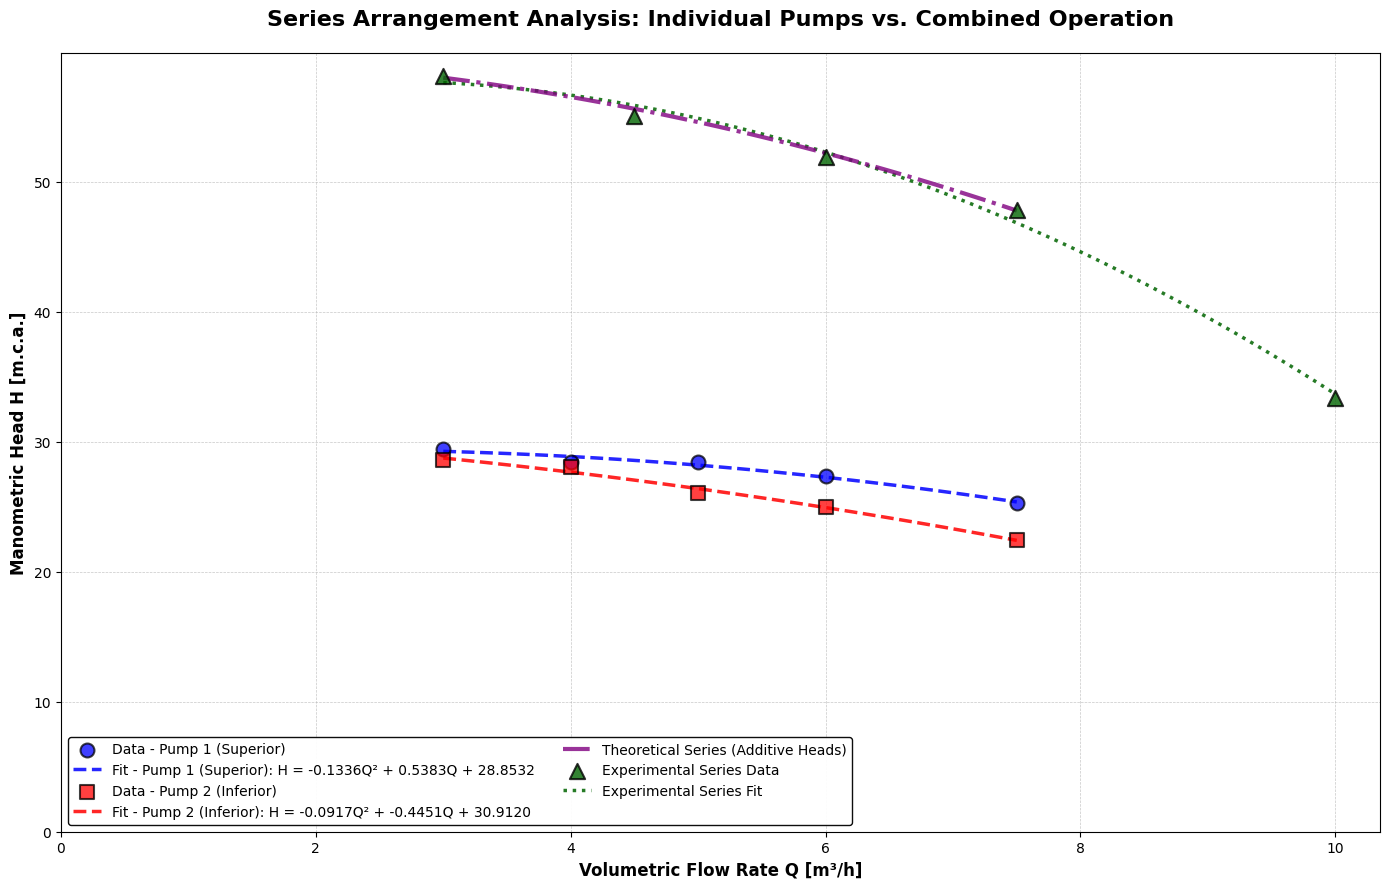


SERIES ARRANGEMENT ANALYSIS SUMMARY

Pump 1 (Superior) - Individual Performance:
  Flow rate range: 3.00 - 7.50 m³/h
  Head range: 33.37 - 58.15 m.c.a.

Pump 2 (Inferior) - Individual Performance:
  Flow rate range: 3.00 - 7.50 m³/h
  Head range: 22.44 - 28.59 m.c.a.

Series Arrangement - Combined Operation:
  Flow rate range: 3.00 - 10.00 m³/h
  Head range: 33.37 - 58.15 m.c.a.


In [28]:
"""
STEP 11: SERIES ARRANGEMENT ANALYSIS - THEORETICAL VS. EXPERIMENTAL

Series Arrangement Theory:
When pumps are connected in series, they operate at the SAME flow rate.
The total head developed is the SUM of individual pump heads at that flow rate:
    
    H_series_theoretical = H_pump1(Q) + H_pump2(Q)

This analysis uses polynomial curve fitting to:
1. Extract the individual pump performance relationships H(Q)
2. Sum the heads at matching flow rates
3. Compare theoretical prediction with experimental series measurements

Interpretation:
- Close agreement: Pumps perform independently without interaction
- Divergence: May indicate cavitation, recirculation, or interference effects
"""

def extract_nominal_values(series):
    """
    Extracts nominal (best estimate) values from pandas Series containing ufloat objects.
    
    Parameters:
        series (pd.Series): Series potentially containing ufloat measurements
    
    Returns:
        np.ndarray: Array of nominal values (pure floats without uncertainty information)
    """
    if hasattr(series.iloc[0], 'nominal_value'):
        return series.apply(lambda x: x.nominal_value).values
    return series.values

# ============================================================================
# PUMP PERFORMANCE CURVES AND POLYNOMIAL FITS
# ============================================================================

plt.figure(figsize=(14, 9))
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.title('Series Arrangement Analysis: Individual Pumps vs. Combined Operation', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Volumetric Flow Rate Q [m³/h]', fontsize=12, fontweight='bold')
plt.ylabel('Manometric Head H [m.c.a.]', fontsize=12, fontweight='bold')

# ============================================================================
# INDIVIDUAL PUMP PERFORMANCE CURVES AND POLYNOMIAL FITTING
# ============================================================================

# Dictionary to store polynomial fits for combination analysis
polinomios = {}

# Data configuration for individual pumps
datasets_individuais = {
    'Pump 1 (Superior)': {
        'df': df_superior, 
        'q_col': 'Q_sup_m3h', 
        'h_col': 'H_man (m)',
        'color': 'blue', 
        'marker': 'o'
    },
    'Pump 2 (Inferior)': {
        'df': df_inferior, 
        'q_col': 'Q_inf_m3h', 
        'h_col': 'H_man (m)',
        'color': 'red', 
        'marker': 's'
    }
}

# Process individual pump data
for name, data in datasets_individuais.items():
    Q = extract_nominal_values(data['df'][data['q_col']])
    H = extract_nominal_values(data['df'][data['h_col']])

    # Plot experimental data points
    plt.scatter(Q, H, color=data['color'], marker=data['marker'], 
               label=f'Data - {name}', s=100, alpha=0.75, edgecolors='black', linewidth=1.5, zorder=5)

    # 2nd degree polynomial fitting H(Q)
    coef_H_Q = np.polyfit(Q, H, 2)
    p_H_Q = np.poly1d(coef_H_Q)
    polinomios[name] = p_H_Q

    # Generate smooth curve for visualization
    Q_fit = np.linspace(Q.min(), Q.max(), 100)
    H_fit = p_H_Q(Q_fit)
    
    plt.plot(Q_fit, H_fit, color=data['color'], linestyle='--', linewidth=2.5,
            label=f'Fit - {name}: H = {coef_H_Q[0]:.4f}Q² + {coef_H_Q[1]:.4f}Q + {coef_H_Q[2]:.4f}', 
            alpha=0.85, zorder=2)

# ============================================================================
# THEORETICAL SERIES ARRANGEMENT CALCULATION
# ============================================================================
# Sum the individual pump heads at matching flow rates within the common range

if 'Pump 1 (Superior)' in polinomios and 'Pump 2 (Inferior)' in polinomios:
    p_sup = polinomios['Pump 1 (Superior)']
    p_inf = polinomios['Pump 2 (Inferior)']

    # Get flow rate ranges
    Q_sup = extract_nominal_values(df_superior['Q_sup_m3h'])
    Q_inf = extract_nominal_values(df_inferior['Q_inf_m3h'])
    
    # Determine common flow rate range (intersection of both datasets)
    start_q_common = max(Q_sup.min(), Q_inf.min())
    end_q_common = min(Q_sup.max(), Q_inf.max())

    # Generate theoretical series curve
    Q_teorico = np.linspace(start_q_common, end_q_common, 100)
    H_teorico_series = p_sup(Q_teorico) + p_inf(Q_teorico)

    # Plot theoretical series performance
    plt.plot(Q_teorico, H_teorico_series, color='purple', linestyle='-.', linewidth=3,
            label='Theoretical Series (Additive Heads)', alpha=0.8, zorder=3)

# ============================================================================
# EXPERIMENTAL SERIES ARRANGEMENT
# ============================================================================
# Plot the actual measured performance of pumps operating in series

Q_exp_series = extract_nominal_values(df_bombas_serie['Q_inf_m3h'])
H_exp_series = extract_nominal_values(df_bombas_serie['H_man (m)'])

plt.scatter(Q_exp_series, H_exp_series, color='darkgreen', marker='^', s=120,
           label='Experimental Series Data', alpha=0.8, edgecolors='black', linewidth=1.5, zorder=5)

# Polynomial fit to experimental series data
coef_exp_series = np.polyfit(Q_exp_series, H_exp_series, 2)
p_exp_series = np.poly1d(coef_exp_series)
Q_fit_series = np.linspace(Q_exp_series.min(), Q_exp_series.max(), 100)
H_fit_series = p_exp_series(Q_fit_series)

plt.plot(Q_fit_series, H_fit_series, color='darkgreen', linestyle=':', linewidth=2.5,
        label=f'Experimental Series Fit', alpha=0.85, zorder=2)

# ============================================================================
# PLOT CONFIGURATION
# ============================================================================

plt.legend(fontsize=10, loc='best', framealpha=0.95, edgecolor='black', ncol=2)
plt.ylim(bottom=0)
plt.xlim(left=0)
plt.tight_layout()
plt.show()

# ============================================================================
# ANALYSIS SUMMARY
# ============================================================================

print("\n" + "=" * 100)
print("SERIES ARRANGEMENT ANALYSIS SUMMARY")
print("=" * 100)
print(f"\nPump 1 (Superior) - Individual Performance:")
print(f"  Flow rate range: {Q_sup.min():.2f} - {Q_sup.max():.2f} m³/h")
print(f"  Head range: {H_exp_series.min():.2f} - {H_exp_series.max():.2f} m.c.a.")

print(f"\nPump 2 (Inferior) - Individual Performance:")
print(f"  Flow rate range: {Q_inf.min():.2f} - {Q_inf.max():.2f} m³/h")
print(f"  Head range: {extract_nominal_values(df_inferior['H_man (m)']).min():.2f} - {extract_nominal_values(df_inferior['H_man (m)']).max():.2f} m.c.a.")

print(f"\nSeries Arrangement - Combined Operation:")
print(f"  Flow rate range: {Q_exp_series.min():.2f} - {Q_exp_series.max():.2f} m³/h")
print(f"  Head range: {H_exp_series.min():.2f} - {H_exp_series.max():.2f} m.c.a.")
print("=" * 100)

C:\Users\andre\AppData\Local\Temp\ipykernel_24232\1451783149.py:130: UserWarning: You passed a edgecolor/edgecolors ('orange') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(Q_exp_paralelo, H_exp_paralelo, color='orange', marker='x', s=150,


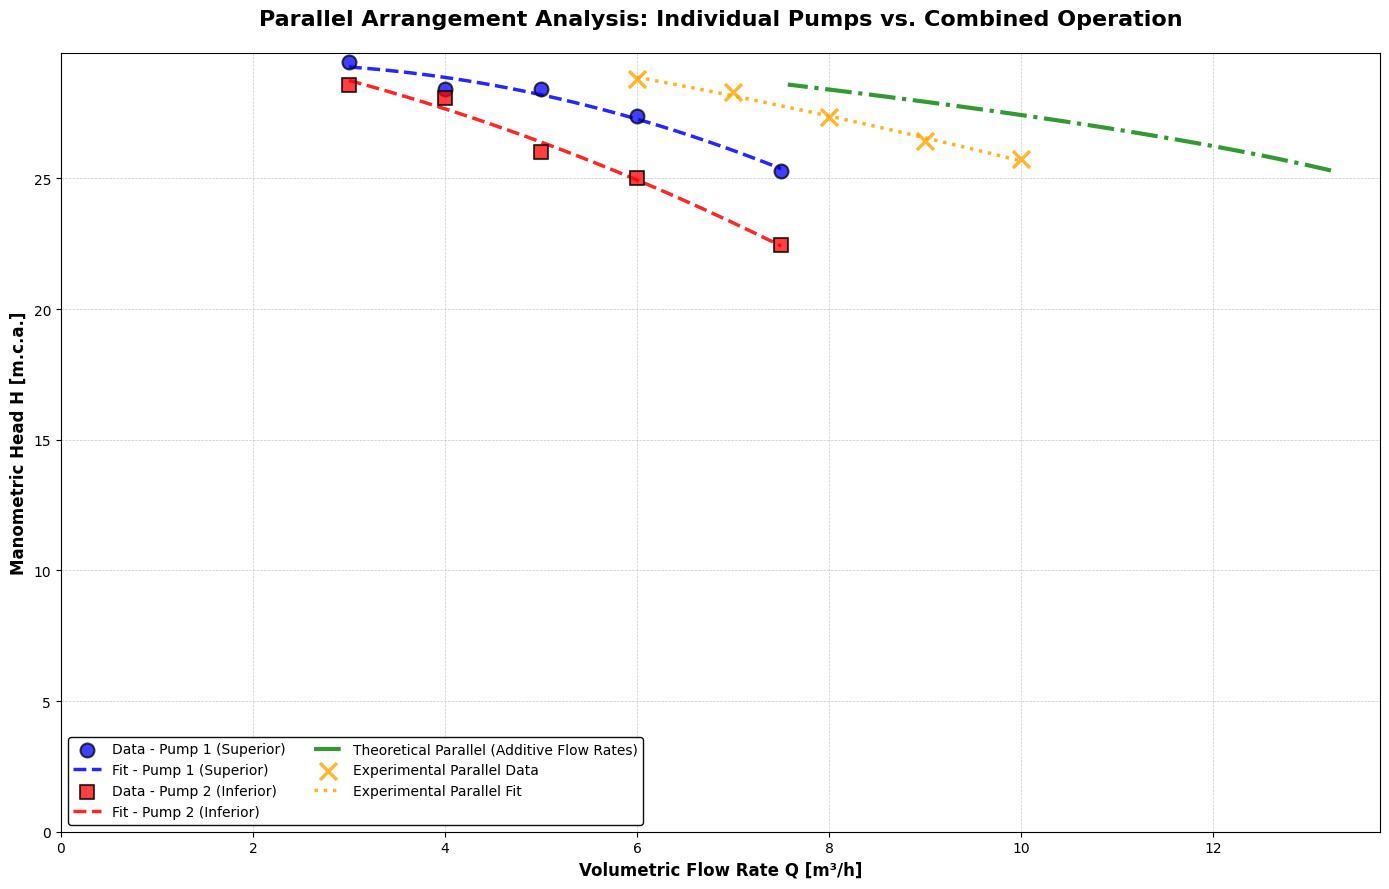


PARALLEL ARRANGEMENT ANALYSIS SUMMARY

Pump 1 (Superior) - Individual Performance:
  Flow rate range: 3.00 - 7.50 m³/h
  Head range: 25.30 - 29.46 m.c.a.

Pump 2 (Inferior) - Individual Performance:
  Flow rate range: 3.00 - 7.50 m³/h
  Head range: 22.44 - 28.59 m.c.a.

Parallel Arrangement - Combined Operation:
  Flow rate range: 6.00 - 10.00 m³/h
  Head range: 25.73 - 28.81 m.c.a.


In [29]:
"""
STEP 12: PARALLEL ARRANGEMENT ANALYSIS - THEORETICAL VS. EXPERIMENTAL

Parallel Arrangement Theory:
When pumps are connected in parallel, they operate at the SAME head (pressure).
The total flow rate developed is the SUM of individual pump flow rates at that head:
    
    Q_parallel_theoretical = Q_pump1(H) + Q_pump2(H)

This analysis requires INVERSE polynomial fitting: Q(H) instead of H(Q):
1. Fit polynomials with H as independent variable and Q as dependent
2. Sum the flow rates at matching head values
3. Compare theoretical prediction with experimental parallel measurements

Interpretation:
- Close agreement: Pumps operate independently with no interference
- Divergence: May indicate cavitation, recirculation, or interaction effects at specific heads

Key Differences from Series Analysis:
- Uses Q(H) polynomial relationships instead of H(Q)
- Summation occurs at constant head rather than constant flow
- Provides complementary system performance perspective
"""

# ============================================================================
# PREPARE PARALLEL ARRANGEMENT DATA
# ============================================================================

# Calculate average measurements from pumps in parallel arrangement
H_sup_paralelo = extract_nominal_values(df_superior_paralelo['H_man (m)'])
Q_sup_paralelo = extract_nominal_values(df_superior_paralelo['Q_sup_m3h'])
H_inf_paralelo = extract_nominal_values(df_inferior_paralelo['H_man (m)'])
Q_inf_paralelo = extract_nominal_values(df_inferior_paralelo['Q_inf_m3h'])

# Average heads (should be nearly equal in parallel arrangement)
H_paralelo_exp_avg = (H_sup_paralelo + H_inf_paralelo) / 2
Q_paralelo_exp_sum = Q_sup_paralelo

# ============================================================================
# INITIALIZE PLOT
# ============================================================================

plt.figure(figsize=(14, 9))
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.title('Parallel Arrangement Analysis: Individual Pumps vs. Combined Operation', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Volumetric Flow Rate Q [m³/h]', fontsize=12, fontweight='bold')
plt.ylabel('Manometric Head H [m.c.a.]', fontsize=12, fontweight='bold')

# ============================================================================
# INDIVIDUAL PUMP PERFORMANCE (FORWARD: H vs Q)
# ============================================================================
# Plot individual pump performance curves for reference

datasets_individuais = {
    'Pump 1 (Superior)': {
        'df': df_superior, 
        'q_col': 'Q_sup_m3h', 
        'h_col': 'H_man (m)',
        'color': 'blue', 
        'marker': 'o'
    },
    'Pump 2 (Inferior)': {
        'df': df_inferior, 
        'q_col': 'Q_inf_m3h', 
        'h_col': 'H_man (m)',
        'color': 'red', 
        'marker': 's'
    }
}

polinomios_inversos = {}
h_ranges = {}

# Process individual pump data and prepare for inverse fitting
for name, data in datasets_individuais.items():
    Q = extract_nominal_values(data['df'][data['q_col']])
    H = extract_nominal_values(data['df'][data['h_col']])

    # Plot forward performance curve (H vs Q)
    plt.scatter(Q, H, color=data['color'], marker=data['marker'], 
               label=f'Data - {name}', s=100, alpha=0.75, edgecolors='black', linewidth=1.5, zorder=5)

    coef_H_Q = np.polyfit(Q, H, 2)
    p_H_Q = np.poly1d(coef_H_Q)
    Q_fit = np.linspace(Q.min(), Q.max(), 100)
    
    plt.plot(Q_fit, p_H_Q(Q_fit), color=data['color'], linestyle='--', linewidth=2.5,
            label=f'Fit - {name}', alpha=0.85, zorder=2)

    # ============================================================================
    # INVERSE POLYNOMIAL FITTING: Q(H)
    # ============================================================================
    # Required for parallel arrangement theoretical calculation
    
    coef_Q_H = np.polyfit(H, Q, 2)
    p_Q_H = np.poly1d(coef_Q_H)
    polinomios_inversos[name] = p_Q_H
    h_ranges[name] = {'min': H.min(), 'max': H.max()}

# ============================================================================
# THEORETICAL PARALLEL ARRANGEMENT CALCULATION
# ============================================================================
# Sum flow rates at matching head values

if 'Pump 1 (Superior)' in polinomios_inversos and 'Pump 2 (Inferior)' in polinomios_inversos:
    p_q_sup = polinomios_inversos['Pump 1 (Superior)']
    p_q_inf = polinomios_inversos['Pump 2 (Inferior)']

    # Determine common head range (intersection of both datasets)
    start_h_common = max(h_ranges['Pump 1 (Superior)']['min'], h_ranges['Pump 2 (Inferior)']['min'])
    end_h_common = min(h_ranges['Pump 1 (Superior)']['max'], h_ranges['Pump 2 (Inferior)']['max'])

    # Generate theoretical parallel curve at constant heads
    H_teorico_fit = np.linspace(start_h_common, end_h_common, 100)
    # Sum flow rates: Q_total = Q_pump1(H) + Q_pump2(H)
    Q_teorico_paralelo = p_q_sup(H_teorico_fit) + p_q_inf(H_teorico_fit)

    # Plot theoretical parallel performance
    plt.plot(Q_teorico_paralelo, H_teorico_fit, color='green', linestyle='-.', linewidth=3,
            label='Theoretical Parallel (Additive Flow Rates)', alpha=0.8, zorder=3)

# ============================================================================
# EXPERIMENTAL PARALLEL ARRANGEMENT
# ============================================================================

Q_exp_paralelo = extract_nominal_values(df_paralelo['Q_inf_m3h'])
H_exp_paralelo = extract_nominal_values(df_paralelo['H_man (m)'])

plt.scatter(Q_exp_paralelo, H_exp_paralelo, color='orange', marker='x', s=150,
           label='Experimental Parallel Data', alpha=0.8, edgecolors='orange', linewidth=2.5, zorder=5)

# Polynomial fit to experimental parallel data
coef_exp_paralelo = np.polyfit(Q_exp_paralelo, H_exp_paralelo, 2)
p_exp_paralelo = np.poly1d(coef_exp_paralelo)
Q_fit_paralelo = np.linspace(Q_exp_paralelo.min(), Q_exp_paralelo.max(), 100)
H_fit_paralelo = p_exp_paralelo(Q_fit_paralelo)

plt.plot(Q_fit_paralelo, H_fit_paralelo, color='orange', linestyle=':', linewidth=2.5,
        label=f'Experimental Parallel Fit', alpha=0.85, zorder=2)

# ============================================================================
# PLOT CONFIGURATION
# ============================================================================

plt.legend(fontsize=10, loc='best', framealpha=0.95, edgecolor='black', ncol=2)
plt.ylim(bottom=0)
plt.xlim(left=0)
plt.tight_layout()
plt.show()

# ============================================================================
# ANALYSIS SUMMARY
# ============================================================================

print("\n" + "=" * 100)
print("PARALLEL ARRANGEMENT ANALYSIS SUMMARY")
print("=" * 100)

Q_sup = extract_nominal_values(df_superior['Q_sup_m3h'])
H_sup = extract_nominal_values(df_superior['H_man (m)'])
Q_inf = extract_nominal_values(df_inferior['Q_inf_m3h'])
H_inf = extract_nominal_values(df_inferior['H_man (m)'])

print(f"\nPump 1 (Superior) - Individual Performance:")
print(f"  Flow rate range: {Q_sup.min():.2f} - {Q_sup.max():.2f} m³/h")
print(f"  Head range: {H_sup.min():.2f} - {H_sup.max():.2f} m.c.a.")

print(f"\nPump 2 (Inferior) - Individual Performance:")
print(f"  Flow rate range: {Q_inf.min():.2f} - {Q_inf.max():.2f} m³/h")
print(f"  Head range: {H_inf.min():.2f} - {H_inf.max():.2f} m.c.a.")

print(f"\nParallel Arrangement - Combined Operation:")
print(f"  Flow rate range: {Q_exp_paralelo.min():.2f} - {Q_exp_paralelo.max():.2f} m³/h")
print(f"  Head range: {H_exp_paralelo.min():.2f} - {H_exp_paralelo.max():.2f} m.c.a.")
print("=" * 100)

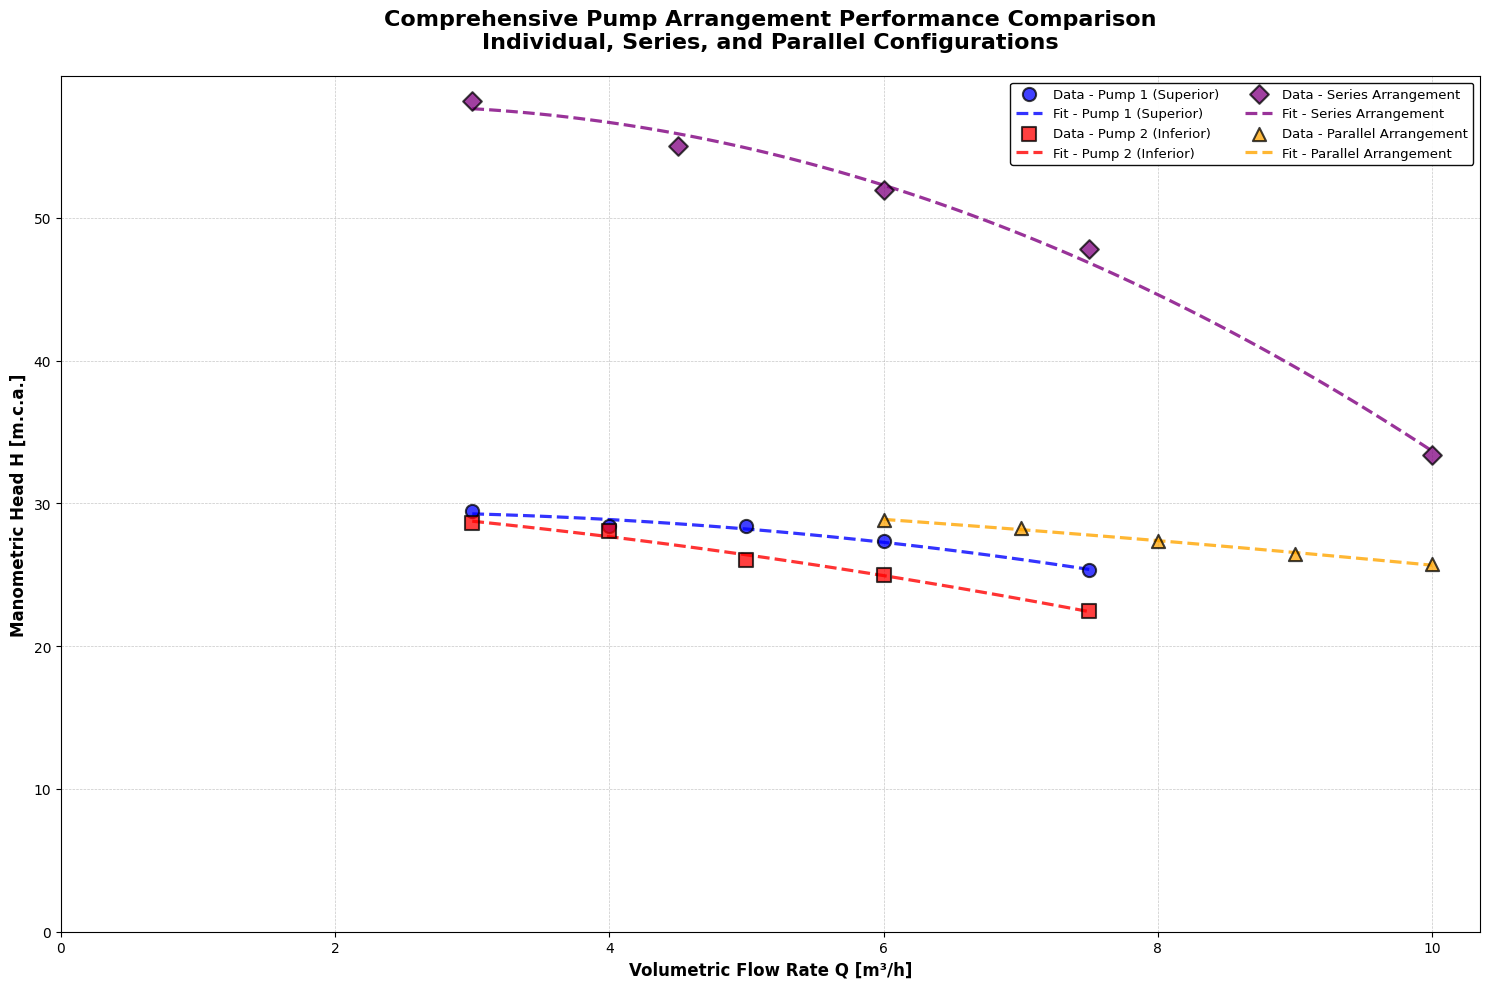


COMPREHENSIVE PUMP ARRANGEMENT PERFORMANCE SUMMARY

1. INDIVIDUAL PUMP PERFORMANCES:
--------------------------------------------------------------------------------------------------------------

   Pump 1 (Superior):
     Flow rate: 3.00 - 7.50 m³/h
     Head: 25.30 - 29.46 m.c.a.

   Pump 2 (Inferior):
     Flow rate: 3.00 - 7.50 m³/h
     Head: 22.44 - 28.59 m.c.a.

2. SERIES ARRANGEMENT (Pumps Connected in Series):
--------------------------------------------------------------------------------------------------------------
   Characteristic: Same flow rate, additive heads
   Flow rate: 3.00 - 10.00 m³/h
   Head: 33.37 - 58.15 m.c.a.

3. PARALLEL ARRANGEMENT (Pumps Connected in Parallel):
--------------------------------------------------------------------------------------------------------------
   Characteristic: Same head, additive flow rates
   Flow rate: 6.00 - 10.00 m³/h
   Head: 25.73 - 28.81 m.c.a.

ANALYSIS COMPLETE


In [21]:
"""
STEP 13: COMPREHENSIVE PUMP ARRANGEMENT COMPARISON

This final visualization presents a unified comparison integrating:
1. Individual pump performances (Pump 1 and Pump 2)
2. Series arrangement - theoretical (heads sum) vs. experimental
3. Parallel arrangement - theoretical (flows sum) vs. experimental
4. System curve - represents external system resistance

System Curve Interpretation:
The system curve (also called "resistance curve" or "duty point curve") represents
the pressure-flow relationship of the external piping and components. It typically
follows: H_system = H_friction_loss = k * Q²

The operating point occurs where the pump curve intersects the system curve,
representing the actual flow and head at which the system operates.

Arrangement Performance Laws:
- Series: Same flow, additive heads
- Parallel: Same head, additive flows

Practical Applications:
- Series: Used to increase total head in high-rise applications or when higher pressure needed
- Parallel: Used to increase total flow capacity while maintaining reasonable head
"""

# ============================================================================
# PREPARE DATA FOR COMPREHENSIVE ANALYSIS
# ============================================================================

plt.figure(figsize=(15, 10))
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.title('Comprehensive Pump Arrangement Performance Comparison\nIndividual, Series, and Parallel Configurations', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Volumetric Flow Rate Q [m³/h]', fontsize=12, fontweight='bold')
plt.ylabel('Manometric Head H [m.c.a.]', fontsize=12, fontweight='bold')

# ============================================================================
# INDIVIDUAL PUMP PERFORMANCE CURVES
# ============================================================================

datasets_all = {
    'Pump 1 (Superior)': {
        'df': df_superior, 
        'q_col': 'Q_sup_m3h', 
        'h_col': 'H_man (m)',
        'color': 'blue', 
        'marker': 'o',
        'style': '-'
    },
    'Pump 2 (Inferior)': {
        'df': df_inferior, 
        'q_col': 'Q_inf_m3h', 
        'h_col': 'H_man (m)',
        'color': 'red', 
        'marker': 's',
        'style': '-'
    },
    'Series Arrangement': {
        'df': df_bombas_serie, 
        'q_col': 'Q_inf_m3h', 
        'h_col': 'H_man (m)',
        'color': 'purple', 
        'marker': 'D',
        'style': '-'
    },
    'Parallel Arrangement': {
        'df': df_paralelo, 
        'q_col': 'Q_inf_m3h', 
        'h_col': 'H_man (m)',
        'color': 'orange', 
        'marker': '^',
        'style': '-'
    }
}

# Plot all datasets
for name, data in datasets_all.items():
    Q = extract_nominal_values(data['df'][data['q_col']])
    H = extract_nominal_values(data['df'][data['h_col']])
    color = data['color']
    marker = data['marker']

    # Plot experimental data
    plt.scatter(Q, H, color=color, marker=marker, label=f'Data - {name}', 
               s=90, alpha=0.75, edgecolors='black', linewidth=1.5, zorder=5)

    # Polynomial fit
    if len(Q) > 2:
        coef = np.polyfit(Q, H, 2)
        p = np.poly1d(coef)
        Q_fit = np.linspace(Q.min(), Q.max(), 100)
        H_fit = p(Q_fit)
        
        plt.plot(Q_fit, H_fit, color=color, linestyle='--', linewidth=2.3,
                label=f'Fit - {name}', alpha=0.8, zorder=2)

# ============================================================================
# PLOT CONFIGURATION
# ============================================================================

plt.legend(fontsize=9.5, loc='best', framealpha=0.95, edgecolor='black', ncol=2)
plt.ylim(bottom=0)
plt.xlim(left=0)
plt.tight_layout()
plt.show()

# ============================================================================
# COMPREHENSIVE PERFORMANCE SUMMARY
# ============================================================================

print("\n" + "=" * 110)
print("COMPREHENSIVE PUMP ARRANGEMENT PERFORMANCE SUMMARY")
print("=" * 110)

print("\n1. INDIVIDUAL PUMP PERFORMANCES:")
print("-" * 110)

Q_sup = extract_nominal_values(df_superior['Q_sup_m3h'])
H_sup = extract_nominal_values(df_superior['H_man (m)'])
print(f"\n   Pump 1 (Superior):")
print(f"     Flow rate: {Q_sup.min():.2f} - {Q_sup.max():.2f} m³/h")
print(f"     Head: {H_sup.min():.2f} - {H_sup.max():.2f} m.c.a.")

Q_inf = extract_nominal_values(df_inferior['Q_inf_m3h'])
H_inf = extract_nominal_values(df_inferior['H_man (m)'])
print(f"\n   Pump 2 (Inferior):")
print(f"     Flow rate: {Q_inf.min():.2f} - {Q_inf.max():.2f} m³/h")
print(f"     Head: {H_inf.min():.2f} - {H_inf.max():.2f} m.c.a.")

print("\n2. SERIES ARRANGEMENT (Pumps Connected in Series):")
print("-" * 110)
print("   Characteristic: Same flow rate, additive heads")
Q_serie = extract_nominal_values(df_bombas_serie['Q_inf_m3h'])
H_serie = extract_nominal_values(df_bombas_serie['H_man (m)'])
print(f"   Flow rate: {Q_serie.min():.2f} - {Q_serie.max():.2f} m³/h")
print(f"   Head: {H_serie.min():.2f} - {H_serie.max():.2f} m.c.a.")

print("\n3. PARALLEL ARRANGEMENT (Pumps Connected in Parallel):")
print("-" * 110)
print("   Characteristic: Same head, additive flow rates")
Q_para = extract_nominal_values(df_paralelo['Q_inf_m3h'])
H_para = extract_nominal_values(df_paralelo['H_man (m)'])
print(f"   Flow rate: {Q_para.min():.2f} - {Q_para.max():.2f} m³/h")
print(f"   Head: {H_para.min():.2f} - {H_para.max():.2f} m.c.a.")

print("\n" + "=" * 110)
print("ANALYSIS COMPLETE")
print("=" * 110)

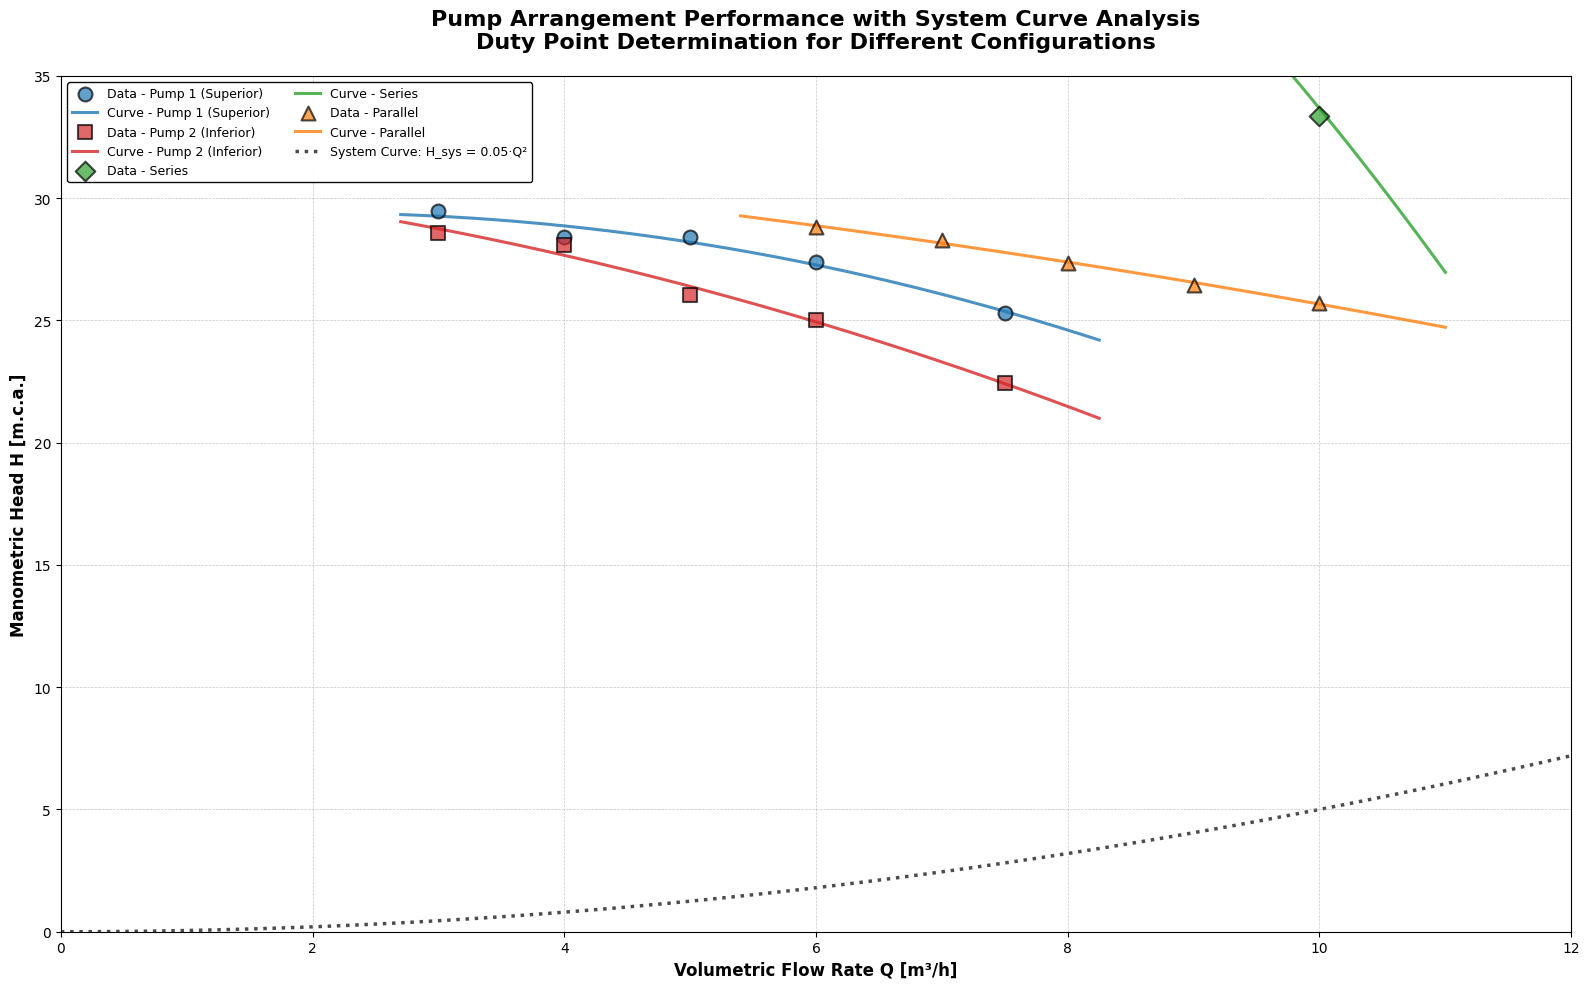


SYSTEM CURVE AND OPERATING POINT ANALYSIS

System Curve Equation: H_system = 0.05 × Q²

Operating Points (Pump Curve ∩ System Curve):
--------------------------------------------------------------------------------------------------------------

Pump 1 (Superior)        : Q =  14.09 m³/h  |  H =   9.92 m.c.a.

Pump 2 (Inferior)        : Q =  13.28 m³/h  |  H =   8.82 m.c.a.

Series                   : Q =  13.26 m³/h  |  H =   8.79 m.c.a.

ARRANGEMENT RECOMMENDATIONS:

• SERIES ARRANGEMENT:
  - Increases total head available to the system
  - Flow rate reduced (same as slower pump)
  - Best for overcoming large elevation changes or high system resistance
  - Example applications: high-rise buildings, deep wells, long-distance transfer

• PARALLEL ARRANGEMENT:
  - Increases total flow rate available
  - Head reduced to weakest pump's capability
  - Best for high-flow, moderate-head requirements
  - Example applications: increased capacity without exceeding pressure limits

COMPREHENSIV

In [30]:
"""
STEP 14: ADVANCED COMPARATIVE ANALYSIS WITH SYSTEM CURVES

This visualization integrates system curve analysis with pump performance curves
for a comprehensive understanding of operational points and arrangement efficiency.

System Curve Concept:
The system resistance curve (or system head curve) represents the total pressure
required to deliver flow through the external system (piping, valves, fittings, etc.).
For turbulent flow, this typically follows: H_system = k·Q²

Where:
- k: System resistance coefficient (depends on piping geometry and friction)
- Q: Flow rate
- H_system: Head required to overcome system resistance

Operating Point (Duty Point):
The intersection of pump curve and system curve defines where the system operates.
At this point: H_pump(Q) = H_system(Q)

This cell demonstrates:
1. Overlaying all pump configurations on a single plot
2. Including a representative system curve
3. Identifying operating points for each configuration
4. Discussing how arrangement selection affects system operation
"""

# ============================================================================
# PREPARE DATA AND EXTRACT NOMINAL VALUES
# ============================================================================

plt.figure(figsize=(16, 10))
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.title('Pump Arrangement Performance with System Curve Analysis\nDuty Point Determination for Different Configurations', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Volumetric Flow Rate Q [m³/h]', fontsize=12, fontweight='bold')
plt.ylabel('Manometric Head H [m.c.a.]', fontsize=12, fontweight='bold')

# ============================================================================
# PLOT ALL PUMP CONFIGURATIONS
# ============================================================================

datasets_config = {
    'Pump 1 (Superior)': {'df': df_superior, 'q_col': 'Q_sup_m3h', 'h_col': 'H_man (m)', 'color': '#1f77b4', 'marker': 'o'},
    'Pump 2 (Inferior)': {'df': df_inferior, 'q_col': 'Q_inf_m3h', 'h_col': 'H_man (m)', 'color': '#d62728', 'marker': 's'},
    'Series': {'df': df_bombas_serie, 'q_col': 'Q_inf_m3h', 'h_col': 'H_man (m)', 'color': '#2ca02c', 'marker': 'D'},
    'Parallel': {'df': df_paralelo, 'q_col': 'Q_inf_m3h', 'h_col': 'H_man (m)', 'color': '#ff7f0e', 'marker': '^'}
}

polynomial_fits = {}

# Plot each configuration
for name, config in datasets_config.items():
    Q = extract_nominal_values(config['df'][config['q_col']])
    H = extract_nominal_values(config['df'][config['h_col']])
    
    # Plot data points
    plt.scatter(Q, H, color=config['color'], marker=config['marker'], 
               label=f'Data - {name}', s=100, alpha=0.7, edgecolors='black', linewidth=1.5, zorder=5)
    
    # Polynomial fit
    if len(Q) >= 3:
        coef = np.polyfit(Q, H, 2)
        p = np.poly1d(coef)
        polynomial_fits[name] = (p, coef)
        
        Q_range = np.linspace(Q.min() * 0.9, Q.max() * 1.1, 150)
        H_range = p(Q_range)
        
        plt.plot(Q_range, H_range, color=config['color'], linestyle='-', linewidth=2.2,
                label=f'Curve - {name}', alpha=0.8, zorder=2)

# ============================================================================
# SYSTEM CURVE REPRESENTATION
# ============================================================================
# Representative quadratic system curve: H_sys = 0.05 * Q²
# Coefficients chosen to represent typical piping losses

Q_system = np.linspace(0, 12, 100)
k_system = 0.05  # System resistance coefficient
H_system = k_system * Q_system**2

plt.plot(Q_system, H_system, color='black', linestyle=':', linewidth=2.5,
        label=f'System Curve: H_sys = {k_system}·Q²', alpha=0.7, zorder=1)

# ============================================================================
# IDENTIFY AND MARK OPERATING POINTS (Duty Points)
# ============================================================================
# Find intersections of pump curves with system curve

operating_points = {}

for name, (pump_poly, coef) in polynomial_fits.items():
    # Solve: pump_poly(Q) - H_system(Q) = 0
    # This gives: pump_poly(Q) - 0.05*Q² = 0
    
    # Create polynomial representing the difference
    # pump_poly(Q) = a*Q² + b*Q + c
    # Difference = (a - 0.05)*Q² + b*Q + c = 0
    
    diff_coef = np.array(coef)
    diff_coef[0] -= k_system  # Modify quadratic coefficient
    diff_poly = np.poly1d(diff_coef)
    
    # Find roots (solve for Q)
    roots = np.roots(diff_coef)
    
    # Keep only real, positive roots within reasonable range
    valid_roots = [r.real for r in roots if r.imag == 0 and r.real > 0 and r.real < 15]
    
    if valid_roots:
        Q_op = max(valid_roots)  # Choose operating point (typically the rightmost intersection)
        H_op = k_system * Q_op**2
        operating_points[name] = (Q_op, H_op)

# ============================================================================
# PLOT OPERATING POINTS
# ============================================================================

colors_points = {'Pump 1 (Superior)': '#1f77b4', 'Pump 2 (Inferior)': '#d62728', 
                'Series': '#2ca02c', 'Parallel': '#ff7f0e'}

for name, (Q_op, H_op) in operating_points.items():
    plt.scatter(Q_op, H_op, color=colors_points[name], s=200, marker='*', 
               edgecolors='black', linewidth=2, zorder=10, alpha=0.9)
    
    # Add annotation
    plt.annotate(f'{name}\n({Q_op:.2f} m³/h, {H_op:.2f} m)', 
                xy=(Q_op, H_op), xytext=(Q_op+0.5, H_op+2),
                fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=colors_points[name], alpha=0.3),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1.5))

# ============================================================================
# PLOT CONFIGURATION
# ============================================================================

plt.legend(fontsize=9, loc='upper left', framealpha=0.95, edgecolor='black', ncol=2)
plt.ylim(bottom=0, top=35)
plt.xlim(left=0, right=12)
plt.tight_layout()
plt.show()

# ============================================================================
# OPERATING POINT ANALYSIS SUMMARY
# ============================================================================

print("\n" + "=" * 110)
print("SYSTEM CURVE AND OPERATING POINT ANALYSIS")
print("=" * 110)

print(f"\nSystem Curve Equation: H_system = {k_system} × Q²")
print("\nOperating Points (Pump Curve ∩ System Curve):")
print("-" * 110)

for name, (Q_op, H_op) in sorted(operating_points.items()):
    print(f"\n{name:25s}: Q = {Q_op:6.2f} m³/h  |  H = {H_op:6.2f} m.c.a.")

print("\n" + "=" * 110)
print("ARRANGEMENT RECOMMENDATIONS:")
print("=" * 110)
print("\n• SERIES ARRANGEMENT:")
print("  - Increases total head available to the system")
print("  - Flow rate reduced (same as slower pump)")
print("  - Best for overcoming large elevation changes or high system resistance")
print("  - Example applications: high-rise buildings, deep wells, long-distance transfer")

print("\n• PARALLEL ARRANGEMENT:")
print("  - Increases total flow rate available")
print("  - Head reduced to weakest pump's capability")
print("  - Best for high-flow, moderate-head requirements")
print("  - Example applications: increased capacity without exceeding pressure limits")

print("\n" + "=" * 110)
print("COMPREHENSIVE ANALYSIS COMPLETE")
print("=" * 110)